In [12]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Bài toán: Dự đoán giá nhà trung bình (California Housing Dataset)")
print(f"Số lượng mẫu: {X.shape[0]} | Số lượng đặc trưng: {X.shape[1]}")
print(f"Tỉ lệ phân chia Train/Test: 70% / 30%\n")

Bài toán: Dự đoán giá nhà trung bình (California Housing Dataset)
Số lượng mẫu: 20640 | Số lượng đặc trưng: 8
Tỉ lệ phân chia Train/Test: 70% / 30%



In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Đã hoàn thành chuẩn hóa dữ liệu cho Linear Regression và KNN!")

Đã hoàn thành chuẩn hóa dữ liệu cho Linear Regression và KNN!


In [14]:
models = {
    "Linear Regression": (LinearRegression(), True),
    "KNN Regressor": (KNeighborsRegressor(), True),
    "Decision Tree Regressor": (DecisionTreeRegressor(random_state=42), False),
    "Random Forest Regressor": (RandomForestRegressor(random_state=42, n_jobs=-1), False),
    "XGBoost Regressor": (XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1, 
        subsample=1.0, colsample_bytree=1.0,
        objective="reg:squarederror", eval_metric="rmse",
        random_state=42, n_jobs=-1
    ), False)
}
print("Đã khởi tạo xong cấu hình 5 mô hình thực nghiệm.")

Đã khởi tạo xong cấu hình 5 mô hình thực nghiệm.


In [15]:
results_list = []
for name, (model, use_scaled) in models.items():
    X_tr = X_train_scaled if use_scaled else X_train.values
    X_te = X_test_scaled if use_scaled else X_test.values

    start_time = time.time()
    model.fit(X_tr, y_train)
    training_time = time.time() - start_time

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    results_list.append({
        "Model": name,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Training Time (s)": training_time
    })

df_results = pd.DataFrame(results_list)
print("============================ BẢNG KẾT QUẢ THỰC NGHIỆM TỔNG HỢP ============================")
print(df_results.to_string(index=False, formatters={
    "Train R2": "{:.4f}".format, "Test R2": "{:.4f}".format,
    "Train RMSE": "{:.4f}".format, "Test RMSE": "{:.4f}".format,
    "Test MAE": "{:.4f}".format, "Training Time (s)": "{:.4f}".format
}))

============================ BẢNG KẾT QUẢ THỰC NGHIỆM TỔNG HỢP ============================
                  Model Train R2 Test R2 Train RMSE Test RMSE Test MAE Training Time (s)
      Linear Regression   0.6093  0.5958     0.7234    0.7284   0.5272            0.0320
          KNN Regressor   0.7910  0.6728     0.5292    0.6554   0.4465            0.0247
Decision Tree Regressor   1.0000  0.5977     0.0000    0.7266   0.4690            0.2691
Random Forest Regressor   0.9724  0.8047     0.1923    0.5063   0.3322            5.5019
      XGBoost Regressor   0.8045  0.7824     0.5118    0.5344   0.3679            0.5141


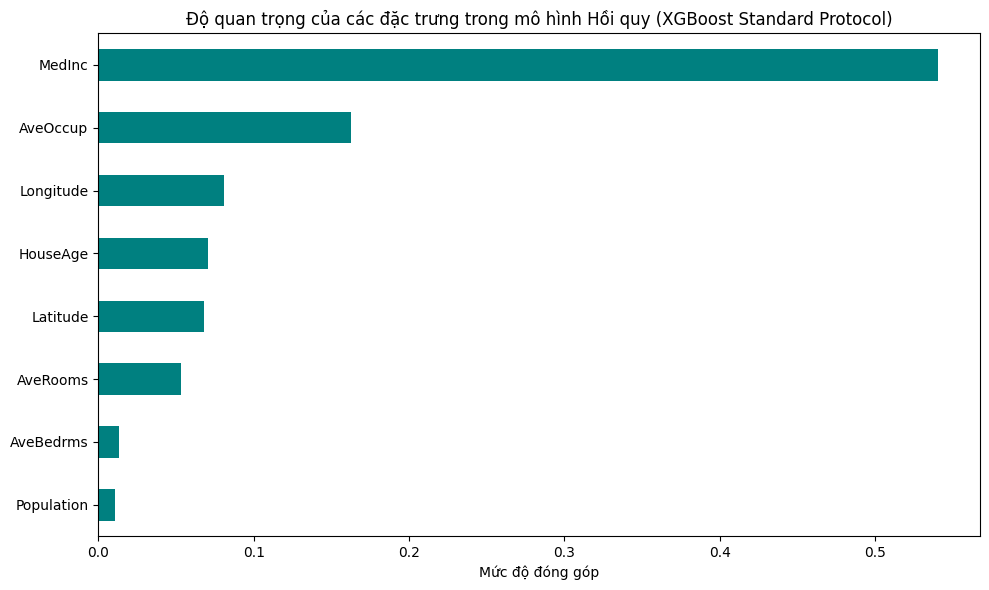

In [16]:
xgb_model = models["XGBoost Regressor"][0]
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Độ quan trọng của các đặc trưng trong mô hình Hồi quy (XGBoost Standard Protocol)')
plt.xlabel('Mức độ đóng góp')
plt.tight_layout()
plt.show()